In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
from matplotlib.pyplot import GridSpec

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [3]:
# data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [4]:
# # get names of all images in dataset_dir/images
# image_names = os.listdir(f"{DATASET_DIR}/images")

# count_images = len(image_names)

In [5]:
# count_images

In [6]:
# # sort image names based on number in name name format is : image_number.png
# image_names.sort(key=lambda x: int(x.split(".")[0].split("_")[1]))

In [7]:
# image_names[-5:]

In [8]:
# label_mapping = {
#     'Benign': 'Benign',
#     'Bot': 'Botnet',
#     'FTP-BruteForce': 'Brute Force',
#     'SSH-Bruteforce': 'Brute Force',
#     'DDoS attacks-LOIC-HTTP': 'DDoS',
#     'DDOS attack-LOIC-UDP': 'DDoS',
#     'DDOS attack-HOIC': 'DDoS',
#     'DoS attacks-GoldenEye': 'DoS',
#     'DoS attacks-Slowloris': 'DoS',
#     'DoS attacks-SlowHTTPTest': 'DoS',
#     'DoS attacks-Hulk': 'DoS',
#     'Infilteration': 'Infiltration',
#     'Brute Force -Web': 'Brute Force',
#     'Brute Force -XSS': 'Brute Force',
#     'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
# }

# data["Label"] = data["Label"].map(label_mapping)

In [9]:
# data["Label"].value_counts()

In [10]:
# data.tail()

In [11]:
# train_data = data.groupby("Label").sample(5000, random_state=42)
# train_data.head()

In [12]:
# train_data_index = train_data.index
# train_data_index

In [13]:
# remaining_data = data[~data.index.isin(train_data_index)]
# remaining_data.head()

In [14]:
# remaining_data["Label"].value_counts()

In [15]:
# # get data for validation and test
# # test data size should be 10k
# val_data = remaining_data.groupby("Label").sample(5000, random_state=42)

# val_data_index = val_data.index

# val_data["Label"].value_counts()

In [16]:
# test_data = remaining_data[~remaining_data.index.isin(val_data_index)]

# test_data["Label"].value_counts()

In [17]:
# def clean_image_path(image_path):
#     return os.path.basename(image_path)

# # store images and labels in a dataframe
# def store_images_and_labels(data_index, bin_labels, datatype):
#     images = []
#     labels = []

#     images_dir = f"{DATASET_DIR}/images"

#     for index in data_index:
#         image_path = f"{images_dir}/image_{index}.png"
#         images.append(image_path)
#         labels.append(bin_labels[index])

#     df = pd.DataFrame({
#         "Image": images,
#         "Label": labels
#     })


#     df["Image"] = df["Image"].apply(clean_image_path)

#     df.to_csv(f"{DATASET_DIR}/{datatype}.csv", index=False)

#     return df

# # images = []
# # labels = []

# # images_dir = f"{DATASET_DIR}/images"

# # with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
# #     all_labels = pickle.load(f)

# # for index in train_data_index:
# #     # images are grayscale, with mode L
# #     image_path = f"{images_dir}/image_{index}.png"
# #     images.append(image_path)
# #     labels.append(all_labels[index])


# # train_df = pd.DataFrame({
# #     "Image": images,
# #     "Label": labels
# # })


# with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
#     all_labels = pickle.load(f)


# train_df = store_images_and_labels(train_data_index, all_labels, "train")

In [18]:
# val_df = store_images_and_labels(val_data_index, all_labels, "val")
# test_df = store_images_and_labels(test_data.index, all_labels, "test")

In [19]:
train_df = pd.read_csv(f"{DATASET_DIR}/train.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test.csv")

In [20]:
train_df["Label"].value_counts()

Label
Malicious    25000
Benign        5000
Name: count, dtype: int64

In [21]:
# verify the images in train are not in val or test
train_images = set(train_df["Image"])
val_images = set(val_df["Image"])
test_images = set(test_df["Image"])

assert len(train_images.intersection(val_images)) == 0
assert len(train_images.intersection(test_images)) == 0

# verify the images in val are not in test
assert len(val_images.intersection(test_images)) == 0

In [22]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [23]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,1
1,image_2975672.png,1
2,image_6489183.png,1
3,image_2675390.png,1
4,image_5559062.png,1


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    # transforms.RandomHorizontalFlip(),  # randomly flip images horizontally
    # transforms.RandomRotation(10),      # slight random rotation
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # random translation
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

# Keep validation transforms simple - just basic preprocessing
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=train_transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=val_transform)

In [ ]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [26]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [27]:
class BinaryCNN2(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN2, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
            
        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 2 * 2 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
            # nn.ReLU(),
            # nn.Dropout(0.2),

            # nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

class BinaryCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding="same"),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
            
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

class BinaryCNN3(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN3, self).__init__()
        
        # Feature extraction layers
        self.conv1 = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
        )

        self.conv2 = nn.Sequential(
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        # print(x.shape)
        x = self.conv2(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

In [28]:
# dummy = torch.randn(1, 1, 32, 32)
# model = BinaryCNN()
# model(dummy)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_sigmoid = nn.BCELoss
criterion_logits = nn.BCEWithLogitsLoss
criterion_cross_entropy = nn.CrossEntropyLoss

In [30]:
# calculate metrics for binary classification
# accuracy, precision, recall, f1 score
# use sklearn to calculate these metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary")
    recall = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")
    
    return accuracy, precision, recall, f1

def calculate_class_metrics(y_true, y_pred):
    """Calculate metrics for each class separately."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


    overall_accuracy = accuracy_score(y_true, y_pred)

    benign_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0
    malicious_accuracy = tn / (tn + fp) if (tn + fp) > 0 else 0

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'overall_accuracy': overall_accuracy,
        'benign': {
            'accuracy': benign_accuracy,
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'accuracy': malicious_accuracy,
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [31]:
# # def train_model(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, model_savepath=None, weight_decay=0.0):
#     model = model_class().to(device)
#     criterion = loss_class(pos_weight=weights) if weights else loss_class()
#     optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

#     best_val_loss = np.inf
#     best_epoch = 0
#     best_model = None
#     early_stop_counter = 0

#     history = {
#         "train_loss": [], "val_loss": [],
#         "benign_metrics": {
#             "train": {"precision": [], "recall": [], "f1": []},
#             "val": {"precision": [], "recall": [], "f1": []}
#         },
#         "malicious_metrics": {
#             "train": {"precision": [], "recall": [], "f1": []},
#             "val": {"precision": [], "recall": [], "f1": []}
#         }
#     }

#     for epoch in range(num_epochs):
#         print(f"\nEpoch {epoch+1}/{num_epochs}")
#         print("-" * 50)

#         # Training phase
#         model.train()
#         train_loss = 0.0
#         train_preds = []
#         train_true = []

#         for images, labels in tqdm(train_dataloader, desc="Training Batches"):
#             images, labels = images.to(device), labels.float().to(device)
            
#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels.view(-1, 1))
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()
#             preds = (torch.sigmoid(outputs) > 0.5).flatten().detach().cpu().numpy()
#             true = labels.squeeze().detach().cpu().numpy()

#             train_preds.extend(preds)
#             train_true.extend(true)

#         train_loss /= len(train_dataloader.dataset)
#         train_metrics = calculate_class_metrics(train_true, train_preds)

#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         val_preds = []
#         val_true = []

#         with torch.no_grad():
#             for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
#                 images, labels = images.to(device), labels.float().to(device)
                
#                 outputs = model(images)
#                 loss = criterion(outputs, labels.view(-1, 1))
#                 val_loss += loss.item()
                
#                 preds = (torch.sigmoid(outputs) > 0.5).flatten().detach().cpu().numpy()
#                 true = labels.squeeze().detach().cpu().numpy()

#                 val_preds.extend(preds)
#                 val_true.extend(true)

#         val_loss /= len(val_dataloader.dataset)
#         val_metrics = calculate_class_metrics(val_true, val_preds)

#         # Update history
#         history["train_loss"].append(train_loss)
#         history["val_loss"].append(val_loss)
        
#         for metric in ["precision", "recall", "f1"]:
#             history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
#             history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
#             history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
#             history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

#         # Print metrics
#         print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
#         print("\nBenign Metrics:")
#         print(f"Train - Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
#         print(f"Val - Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
#         print("\nMalicious Metrics:")
#         print(f"Train - Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
#         print(f"Val - Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")

#         # Early stopping
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_epoch = epoch
#             best_model = model.state_dict()
#             if model_savepath:
#                 torch.save(model.state_dict(), model_savepath)
#             early_stop_counter = 0
#         else:
#             early_stop_counter += 1
#             if early_stop_counter >= early_stop:
#                 print(f"\nEarly stopping at epoch {epoch+1}")
#                 break

#         scheduler.step(val_loss)

#     return best_model, history

In [ ]:
def train_model_reduceonplateau(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class().to(device)
    
    if pos_weights is not None:
        criterion = loss_class(pos_weight=pos_weights)
    elif weights is not None:
        criterion = loss_class(weight=weights)
    else:
        criterion = loss_class()


    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "benign_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        },
        "malicious_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []  # Added to store probabilities

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)
            
            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if loss_class == nn.CrossEntropyLoss:
                probs = outputs.detach().cpu().numpy()
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = np.argmax(probs, axis=1)  # Get predictions


            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)  # Store probabilities

        train_loss /= len(train_dataloader)
        train_metrics = calculate_class_metrics(train_true, train_preds)

        # Validation phase
        # model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []  # Added to store probabilities

        with torch.no_grad():
            model.eval()


            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                if loss_class == nn.CrossEntropyLoss:
                    probs = outputs.detach().cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = np.argmax(probs, axis=1)

                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)  # Store probabilities

        val_loss /= len(val_dataloader)
        val_metrics = calculate_class_metrics(val_true, val_preds)
        

        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
            history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
            history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
            history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

        if debug:
            # Print metrics
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print("\nBenign Metrics:")
            print(f"Train - Accuracy: {train_metrics['benign']['accuracy']:.4f}, Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['benign']['accuracy']:.4f}, Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
            print("\nMalicious Metrics:")
            print(f"Train - Accuracy: {train_metrics['malicious']['accuracy']:.4f}, Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['malicious']['accuracy']:.4f}, Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")
        else:
            # Print loss and overall accuracy
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['overall_accuracy']:.4f}, Val: {val_metrics['overall_accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            if model_savepath:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': val_loss,
                    'scheduler_state_dict': scheduler.state_dict(),
                    'learning_rate': scheduler.get_last_lr(),
                    'history': history
                }, model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        scheduler.step(val_loss)

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [ ]:
def train_model_cosine(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class().to(device)

    if pos_weights is not None:
        criterion = loss_class(pos_weight=pos_weights)
    elif weights is not None:
        criterion = loss_class(weight=weights)
    else:
        criterion = loss_class()


    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # CosineAnnealingWarmRestarts scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=num_epochs // 10,
        T_mult=2,
        eta_min=1e-6
    )

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "benign_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        },
        "malicious_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)

            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            scheduler.step()

            train_loss += loss.item()



            if loss_class == nn.CrossEntropyLoss:
                probs = outputs.detach().cpu().numpy()
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = np.argmax(probs, axis=1)

            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)

        train_loss /= len(train_dataloader)
        train_metrics = calculate_class_metrics(train_true, train_preds)

        # Validation phase
        # model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []

        with torch.no_grad():
            model.eval()

            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                
                if loss_class == nn.CrossEntropyLoss:
                    probs = outputs.detach().cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = np.argmax(probs, axis=1)

                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)

        val_loss /= len(val_dataloader)
        val_metrics = calculate_class_metrics(val_true, val_preds)
        
        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
            history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
            history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
            history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

        if debug:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print("\nBenign Metrics:")
            print(f"Train - Accuracy: {train_metrics['benign']['accuracy']:.4f}, Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['benign']['accuracy']:.4f}, Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
            print("\nMalicious Metrics:")
            print(f"Train - Accuracy: {train_metrics['malicious']['accuracy']:.4f}, Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['malicious']['accuracy']:.4f}, Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")
        else:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['overall_accuracy']:.4f}, Val: {val_metrics['overall_accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            # best_threshold = epoch_best_threshold  # Save the best threshold from this epoch
            if model_savepath:
                torch.save({
                    'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict(),
                    'epoch': epoch,
                    'learning_rate': scheduler.get_last_lr(),
                    'history': history
                }, model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [34]:
# def plot_metrics(history):
#     fig, ax = plt.subplots(2, 2, figsize=(12, 12))

#     ax[0, 0].plot(history["train_loss"], label="Train Loss")
#     ax[0, 0].plot(history["val_loss"], label="Val Loss")
#     ax[0, 0].set_title("Loss")
#     ax[0, 0].legend()

#     ax[0, 1].plot(history["train_accuracy"], label="Train Accuracy")
#     ax[0, 1].plot(history["val_accuracy"], label="Val Accuracy")
#     ax[0, 1].set_title("Accuracy")
#     ax[0, 1].legend()

#     ax[1, 0].plot(history["train_precision"], label="Train Precision")
#     ax[1, 0].plot(history["val_precision"], label="Val Precision")
#     ax[1, 0].set_title("Precision")
#     ax[1, 0].legend()

#     ax[1, 1].plot(history["train_recall"], label="Train Recall")
#     ax[1, 1].plot(history["val_recall"], label="Val Recall")
#     ax[1, 1].set_title("Recall")
#     ax[1, 1].legend()

#     plt.show()

def plot_metrics(history):
    gs = GridSpec(2, 2)
    fig = plt.figure(figsize=(12, 12))

    ax = [
        [fig.add_subplot(gs[0, :])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    ]



    # Loss
    ax[0][0].plot(history["train_loss"], label="Train Loss")
    ax[0][0].plot(history["val_loss"], label="Val Loss")
    ax[0][0].set_title("Loss")
    # ax[0][0].set_ylim(
    ax[0][0].legend()


    # Accuracy
    ax[1][0].plot(history["benign_metrics"]["train"]["accuracy"], label="Train Accuracy")
    ax[1][0].plot(history["benign_metrics"]["val"]["accuracy"], label="Val Accuracy")
    ax[1][0].set_title("Benign Accuracy")
    # ax[1][0].set_ylim(ymin, ymax)
    ax[1][0].legend()

    # Malicious Accuracy
    ax[1][1].plot(history["malicious_metrics"]["train"]["accuracy"], label="Train Accuracy")
    ax[1][1].plot(history["malicious_metrics"]["val"]["accuracy"], label="Val Accuracy")
    ax[1][1].set_title("Malicious Accuracy")
    # ax[1][1].set_ylim(ymin, ymax)
    ax[1][1].legend()


    plt.tight_layout()
    plt.show()


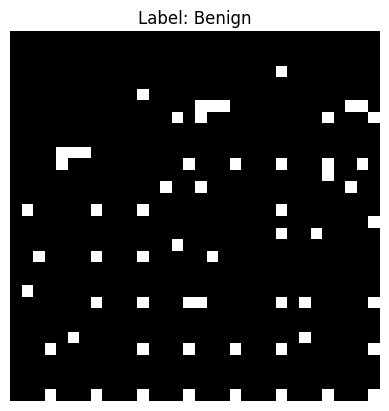

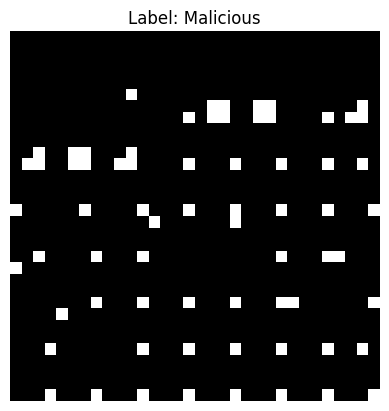

In [35]:
# plot a benign image
def plot_image(image, label):
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()


benign_image = train_dataset[0][0]
plot_image(benign_image, "Benign")

malicious_image = train_dataset[-1][0]
plot_image(malicious_image, "Malicious")

In [36]:
# computer class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_df_encoded["Label"]), y=train_df_encoded["Label"])
class_weights

array([0.6, 3. ])

In [37]:
model_savepath = f"../models/checkpoints/"

pathname_map = {
    'BinaryCNN': "bcnn",
    'BinaryCNN3': "bcnn3",
    'BinaryCNN2': "bcnn2"
}


benign_count = train_df_encoded["Label"].value_counts()[1]
malicious_count = train_df_encoded["Label"].value_counts().sum() - benign_count

pos_weight = torch.tensor([malicious_count / benign_count], dtype=torch.float32).to(device)

total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

pos_weight,

(tensor([5.], device='cuda:0'),)

In [38]:
best_stats = {
    "bcnn" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn2" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn3" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    }
}


for model_class in [BinaryCNN, BinaryCNN2, BinaryCNN3]:
    model_name = model_class.__name__

    model_savepath_cosine = f"{model_savepath}{pathname_map[model_name]}_crossentropy_cosine.pth"
    model_savepath_plateau = f"{model_savepath}{pathname_map[model_name]}_crossentropy_plateau.pth"

    print(f"Training {model_name} with CosineAnnealingWarmRestarts")
    best_model_cos, history_cos = train_model_cosine(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=10, device=device, weights=class_weights, model_savepath=model_savepath_cosine, debug=False)
    best_stats[pathname_map[model_name]]["cos"]["model"] = best_model_cos
    best_stats[pathname_map[model_name]]["cos"]["history"] = history_cos
    # best_stats[pathname_map[model_name]]["cos"]["threshold"] = threshold_cos

    print(f"Training {model_name} with ReduceLROnPlateau")
    best_model_plateau, history_plateau = train_model_reduceonplateau(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=10, device=device, weights=class_weights, model_savepath=model_savepath_plateau, debug=False)
    best_stats[pathname_map[model_name]]["plateau"]["model"] = best_model_plateau
    best_stats[pathname_map[model_name]]["plateau"]["history"] = history_plateau
    # best_stats[pathname_map[model_name]]["plateau"]["threshold"] = threshold_plateau
    print("\n\n")

Training BinaryCNN with CosineAnnealingWarmRestarts

Epoch 1/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:36<00:00, 20.46it/s]



Loss - Train: 0.0057, Val: 0.0106
Accuracy - Train: 0.7980, Val: 0.8187

Epoch 2/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:26<00:00, 28.66it/s]



Loss - Train: 0.0041, Val: 0.0127
Accuracy - Train: 0.8666, Val: 0.8106

Epoch 3/50
--------------------------------------------------


...


Loss - Train: 0.0029, Val: 0.0100
Accuracy - Train: 0.9030, Val: 0.8417

Epoch 18/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:28<00:00, 26.48it/s]



Loss - Train: 0.0029, Val: 0.0099
Accuracy - Train: 0.9028, Val: 0.8426

Epoch 19/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:28<00:00, 26.02it/s]



Loss - Train: 0.0030, Val: 0.0099
Accuracy - Train: 0.9004, Val: 0.8357

Early stopping at epoch 19

Best model was from epoch 9 with validation loss 0.0092





Model: bcnn
CosineAnnealingWarmRestarts


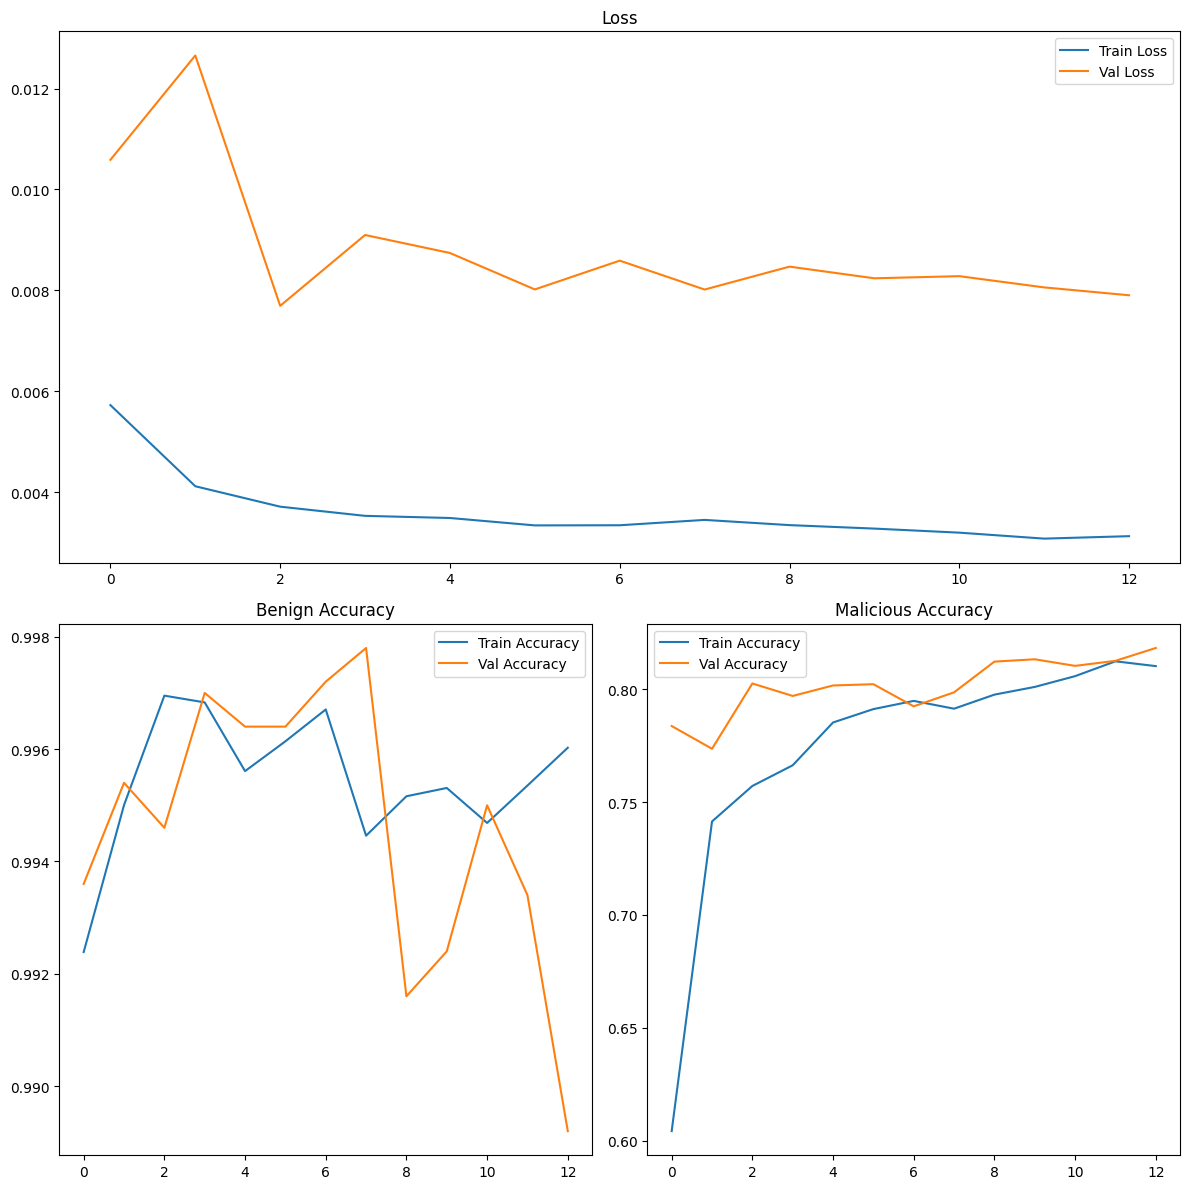

ReduceLROnPlateau


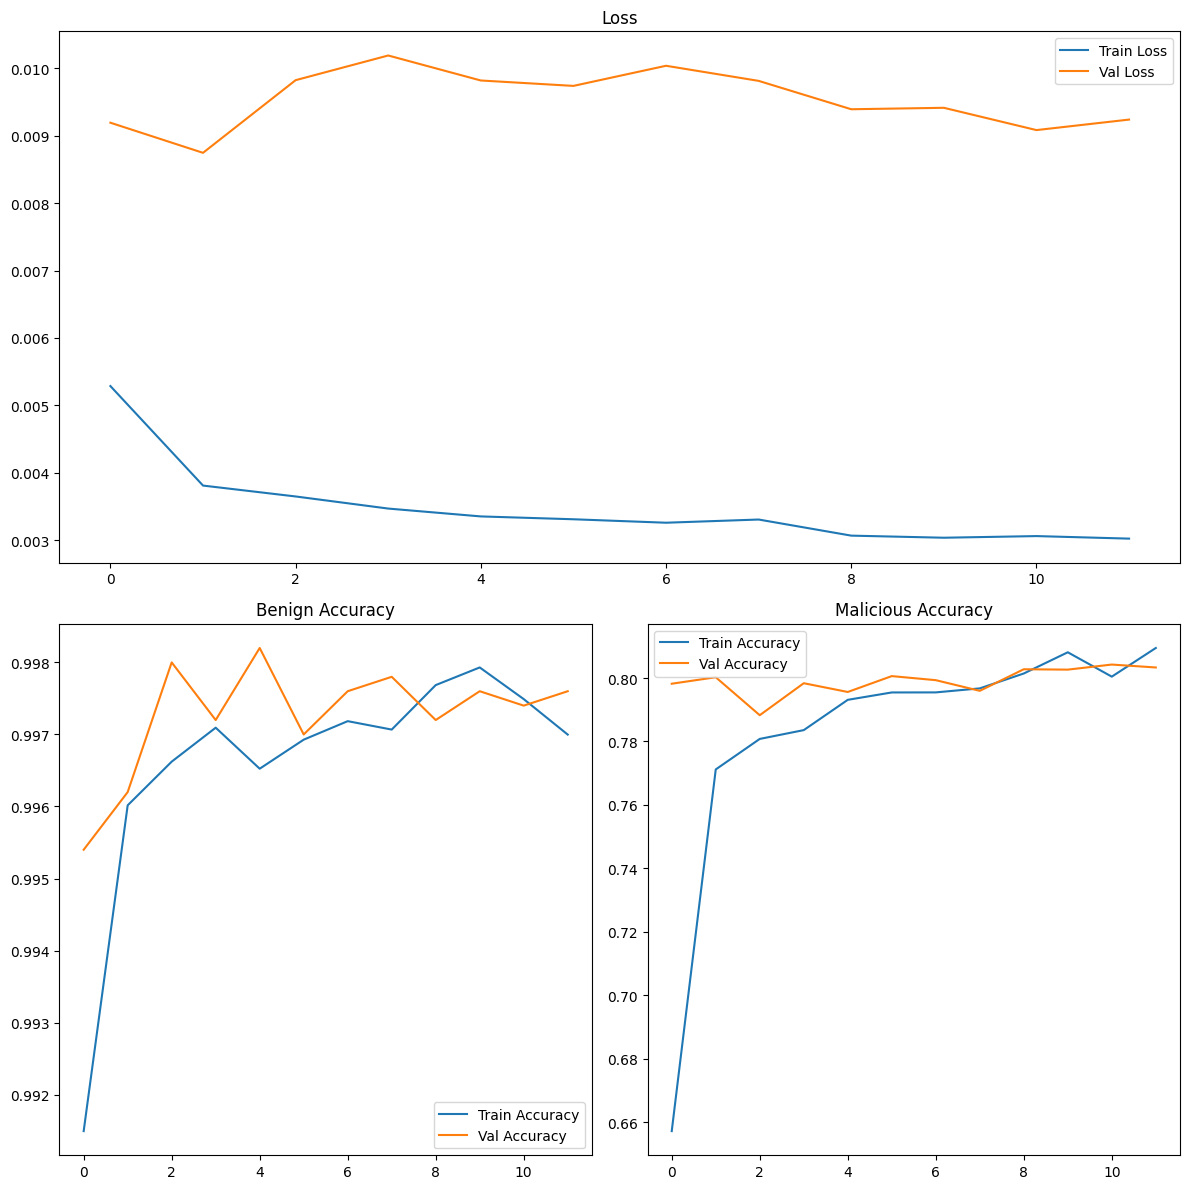




Model: bcnn2
CosineAnnealingWarmRestarts


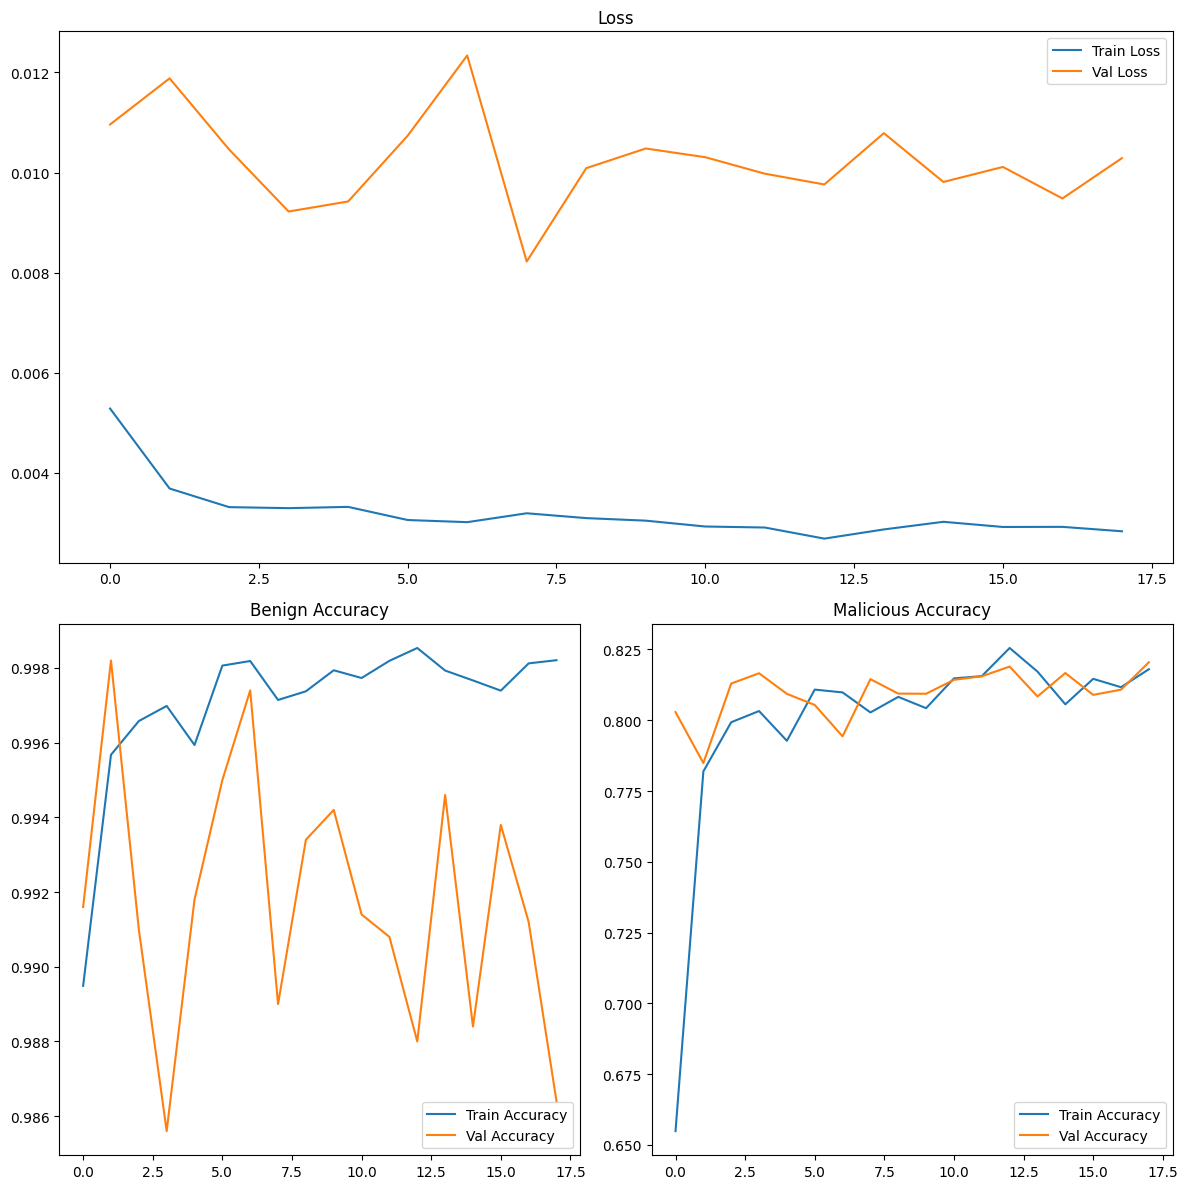

ReduceLROnPlateau


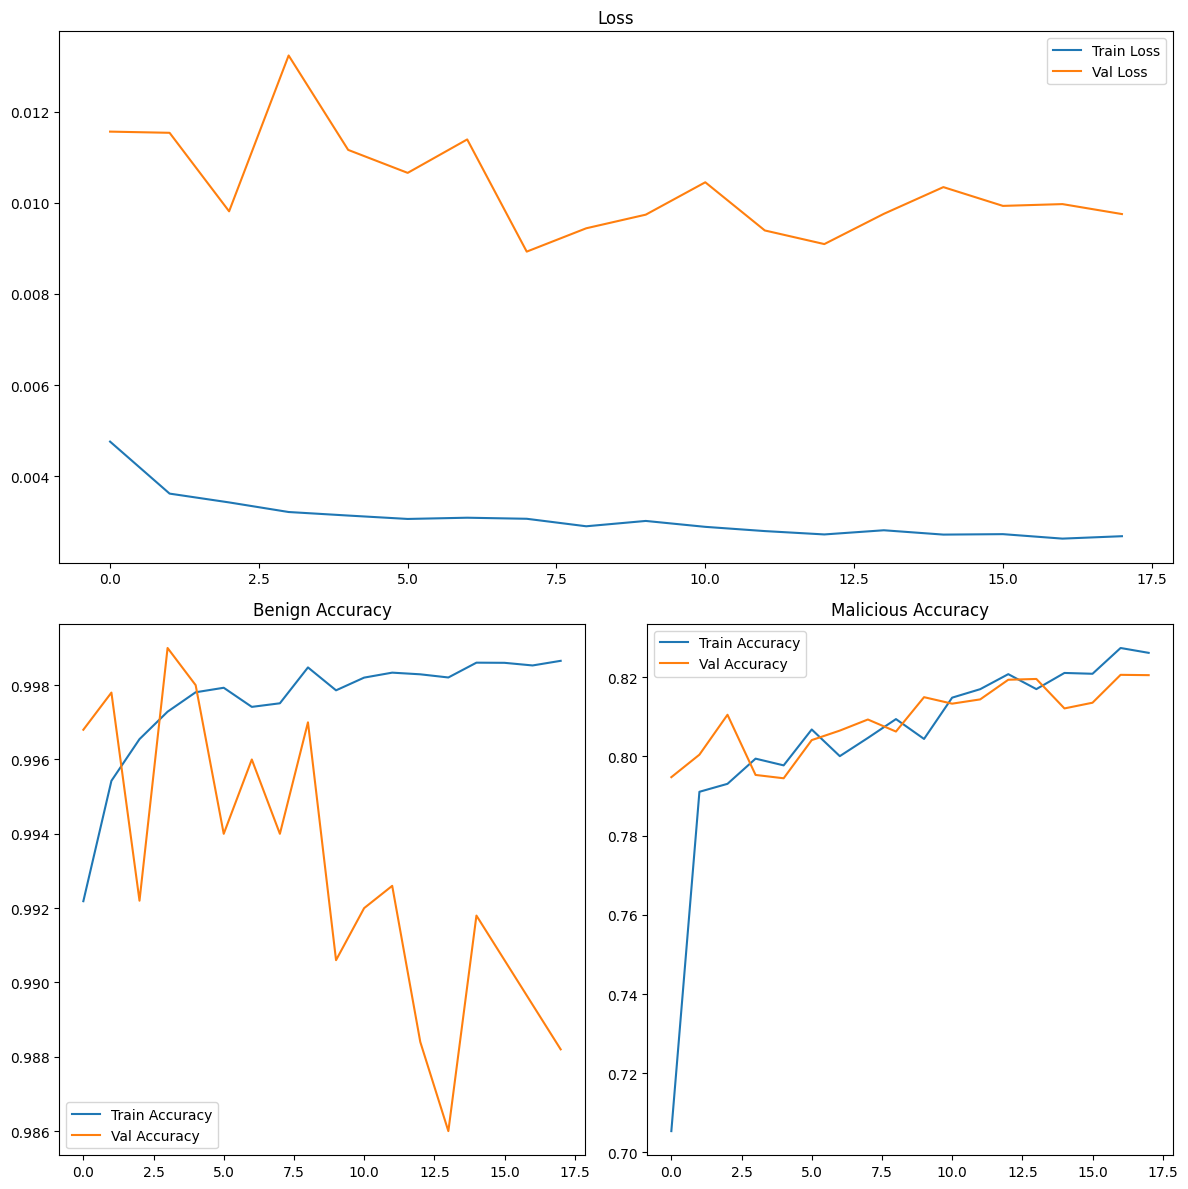




Model: bcnn3
CosineAnnealingWarmRestarts


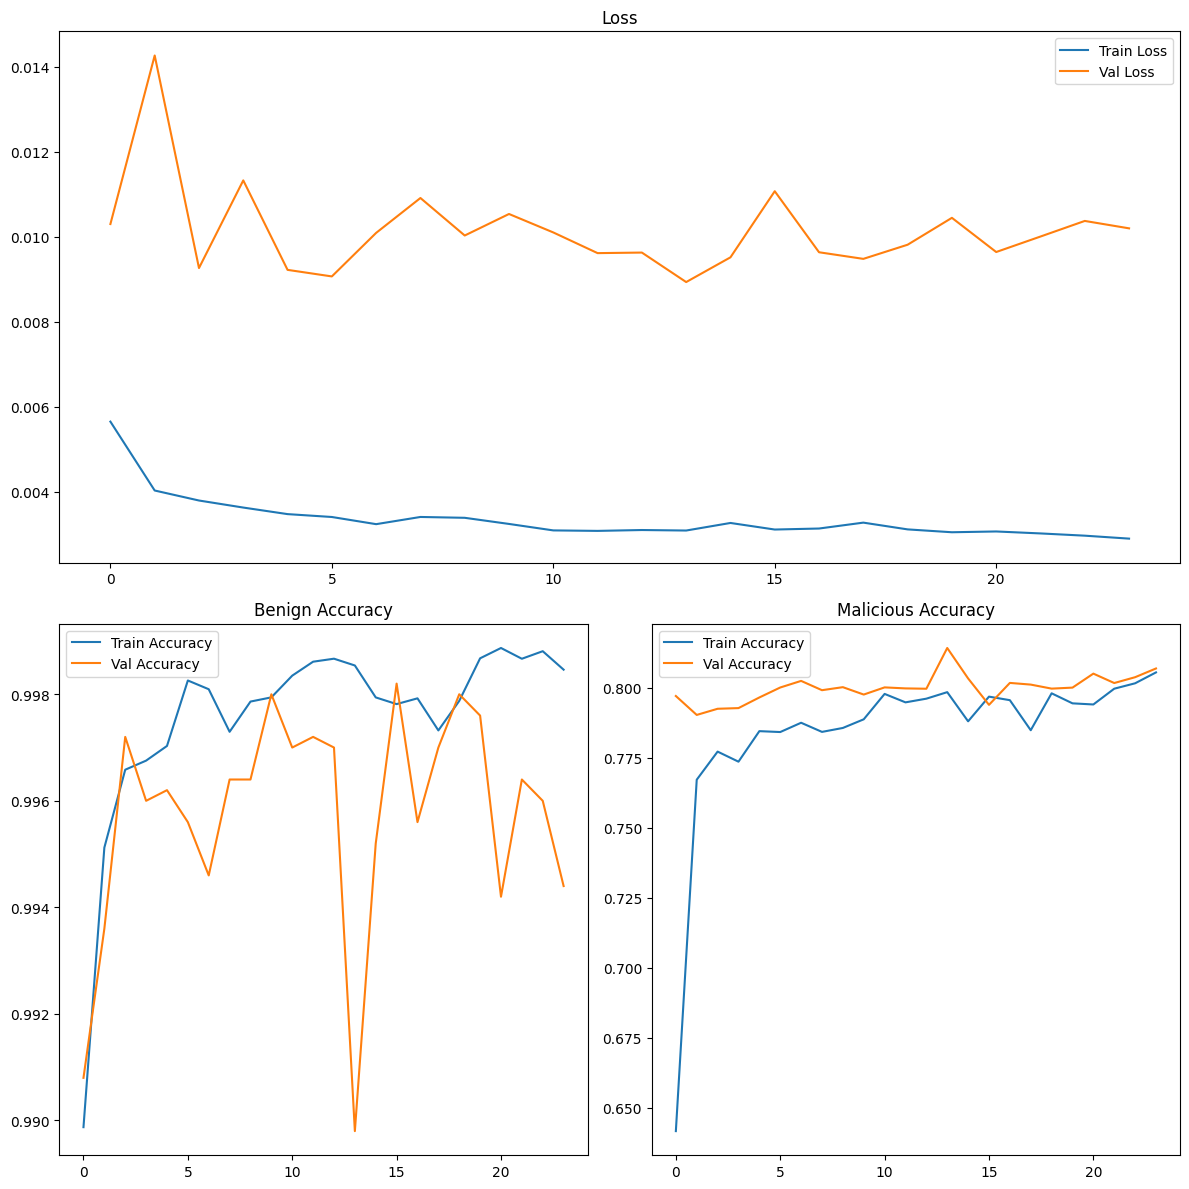

ReduceLROnPlateau


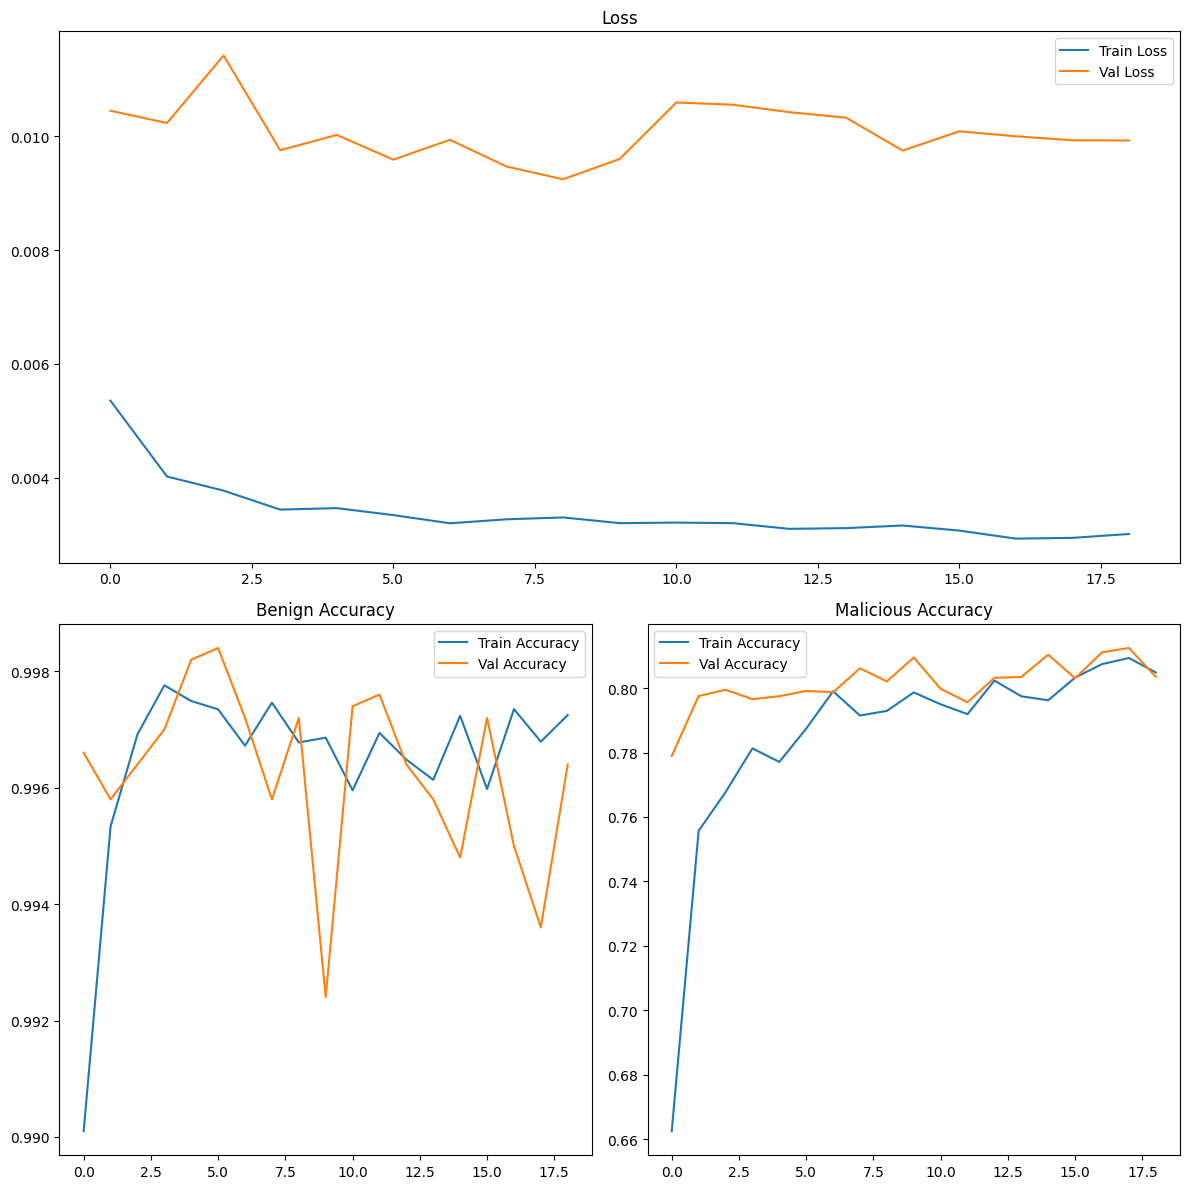

In [39]:
# plot metrics for each model
for model_name, model_stats in best_stats.items():
    print(f"Model: {model_name}")
    print("CosineAnnealingWarmRestarts")
    plot_metrics(model_stats["cos"]["history"])
    print("ReduceLROnPlateau")
    plot_metrics(model_stats["plateau"]["history"])
    print("\n\n")

In [40]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

In [41]:
test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [42]:
from sklearn.metrics import confusion_matrix

def test_model(model, test_dataset, device="cuda"):
    model.eval()
    preds = []
    true = []

    with torch.no_grad():
        for i, (images, labels) in tqdm(enumerate(test_dataset), desc=f"Testing Batches"):
            images, labels = images.to(device), labels.float().to(device)

            outputs = model(images)
            # probs = torch.sigmoid(outputs).detach().cpu().numpy()
            preds.extend(torch.argmax(outputs, dim=1).detach().cpu().numpy())
            true.extend(labels.squeeze().detach().cpu().numpy())

    return true, preds

def test_metrics(true, preds):
    accuracy, precision, recall, f1 = calculate_metrics(true, preds)
    
    # confusion matrix
    cm = confusion_matrix(true, preds)

    # plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title("Confusion Matrix")

    plt.colorbar()

    # 1 is benign, 0 is malicious in predictions and labels

    
    plt.xticks([0, 1], ["Malicious", "Benign"])
    plt.yticks([0, 1], ["Malicious", "Benign"])


    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='red')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")



    plt.show()

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1


In [ ]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

Testing BinaryCNN with CosineAnnealingWarmRestarts


Testing Batches: 250it [00:10, 23.67it/s]


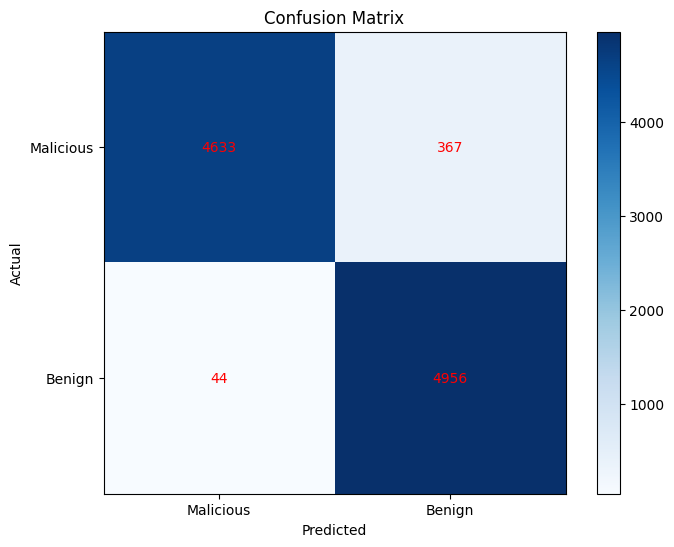

Accuracy: 0.9589
Precision: 0.9311
Recall: 0.9912
F1 Score: 0.9602



Testing BinaryCNN with ReduceLROnPlateau


Testing Batches: 250it [00:07, 33.81it/s]


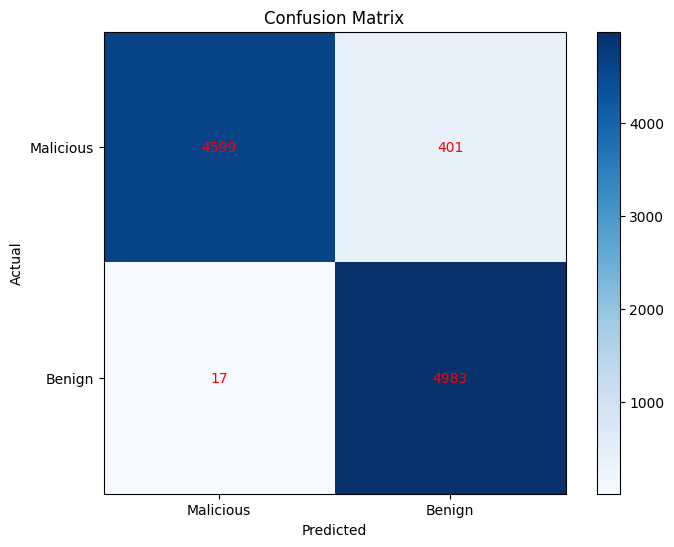

Accuracy: 0.9582
Precision: 0.9255
Recall: 0.9966
F1 Score: 0.9597



Testing BinaryCNN2 with CosineAnnealingWarmRestarts


Testing Batches: 250it [00:07, 33.10it/s]


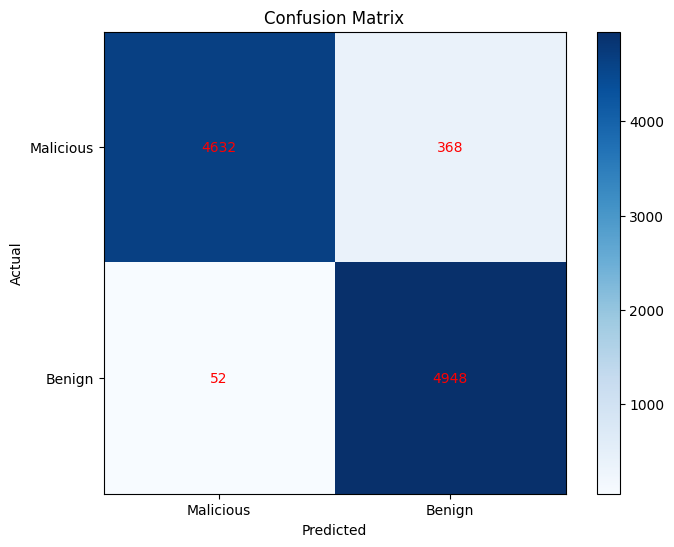

Accuracy: 0.9580
Precision: 0.9308
Recall: 0.9896
F1 Score: 0.9593



Testing BinaryCNN2 with ReduceLROnPlateau


Testing Batches: 250it [00:07, 32.11it/s]


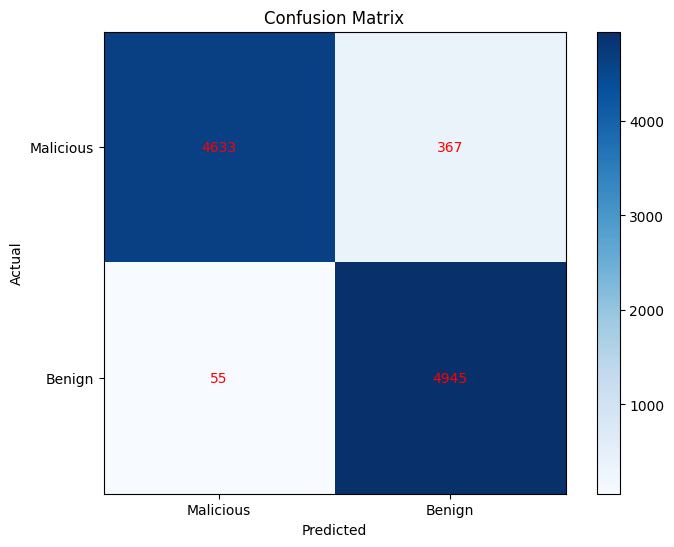

Accuracy: 0.9578
Precision: 0.9309
Recall: 0.9890
F1 Score: 0.9591



Testing BinaryCNN3 with CosineAnnealingWarmRestarts


Testing Batches: 250it [00:07, 32.67it/s]


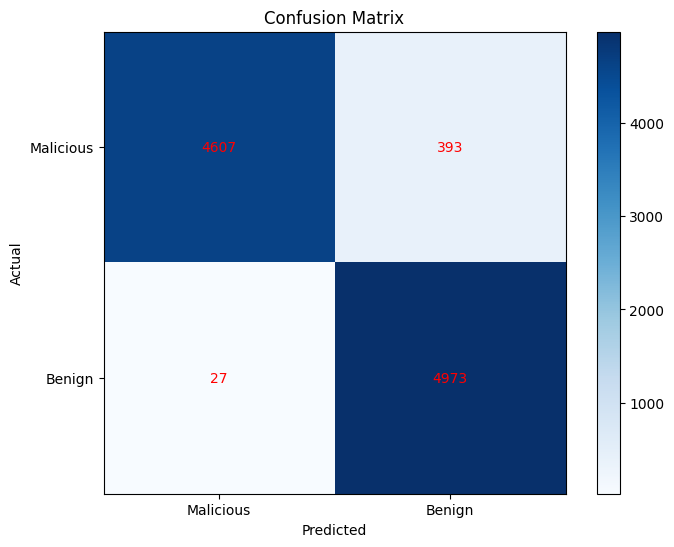

Accuracy: 0.9580
Precision: 0.9268
Recall: 0.9946
F1 Score: 0.9595



Testing BinaryCNN3 with ReduceLROnPlateau


Testing Batches: 250it [00:07, 32.38it/s]


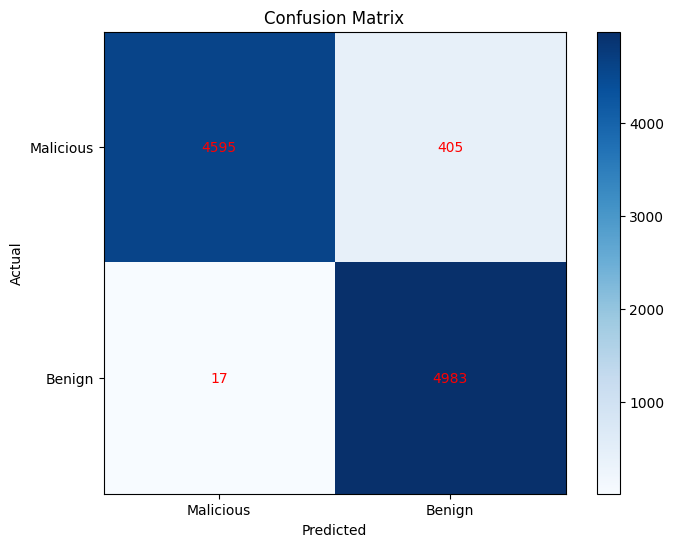

Accuracy: 0.9578
Precision: 0.9248
Recall: 0.9966
F1 Score: 0.9594





In [45]:
# model = BinaryCNN2().to(device)
# model.load_state_dict(torch.load(model_savepath, weights_only=True))


# test each model with the test data
# load model from checkpoint
# calculate metrics for each model

for model_class in [BinaryCNN, BinaryCNN2, BinaryCNN3]:
    model_name = model_class.__name__
    print(f"Testing {model_name} with CosineAnnealingWarmRestarts")
    model = model_class().to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["cos"]["model"])
    true, preds = test_model(model, test_data_loader_sample, device)
    test_metrics(true, preds)
    print("\n\n")

    print(f"Testing {model_name} with ReduceLROnPlateau")
    model = model_class().to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["plateau"]["model"])
    true, preds = test_model(model, test_data_loader_sample, device)
    test_metrics(true, preds)
    print("\n\n")
